# Quantum Speed Limit for GKP State Preparation

The Mandelstam-Tamm bound sets a minimum time
$$
T_\min = \frac{\Omega_B}{\lVert H \rVert}, \qquad \Omega_B = \arccos|\braket{\psi_i | \psi_f}|,
$$
for driving $\ket{\psi_i} \to \ket{\psi_f}$ under any Hamiltonian with spectral-norm bound $\lVert H \rVert$, and this bound is saturated by the quantum brachistochrone construction. For preparing a GKP logical state from the vacuum, $\Omega_B$ is set entirely by the overlap $\braket{\text{vac} | \psi_L}$, which depends sharply on the finite-energy envelope $\Delta$: narrower envelopes (higher effective squeezing) mean less overlap with vacuum, larger $\theta_B$, and longer minimum preparation time. This notebook computes that dependence for each of the six cardinal GKP logical states.


## Imports


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from gkp_optimal_control.plotting import set_plot_style
from gkp_optimal_control.states import gkp_states

set_plot_style()

## System parameters

Square-lattice GKP code with lattice spacings $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$, lattice-sum truncation ``gkp_cutoff``, and unit spectral-norm bound $\lVert H \rVert = \omega$ on the driving Hamiltonian. The Fock truncation $n_{\text{fock}}$ is chosen per envelope $\Delta$ (more squeezing needs more levels); the heuristic below is conservative enough for the $\Delta$ range considered here but should be revisited for very small $\Delta$.


In [2]:
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = np.sqrt(np.pi / 2) * 1j
gkp_cutoff = 10

energy_bound = 1.0
n_fock_min = 50


def fock_cutoff(delta: float) -> int:
    """Heuristic Fock truncation: grows with effective GKP squeezing."""
    squeezing_db = -10 * np.log10(delta**2)
    return max(int(squeezing_db * 15), n_fock_min)

## Bures angle vs GKP envelope

For each envelope $\Delta$ and each cardinal GKP state $\ket{\psi_L}$, compute the Bures angle
$$
\Omega_B(\Delta) = \arccos \bigl| \braket{\mathrm{vac} | \psi_L(\Delta)} \bigr|.
$$
We use the package's `gkp_states` to build $\ket{0_L}$ and $\ket{1_L}$, then form the other four cardinal states as Bloch-sphere superpositions. Each state is embedded in its own Hilbert space sized by ``fock_cutoff(delta)``, so vacuum has to be rebuilt at that dimension for the overlap to be well-defined.


In [3]:
deltas = np.logspace(-1, 0, 10)
squeezings_db = -10 * np.log10(deltas**2)

cardinal_builders = {
    r"0_L":   lambda g0, g1: g0,
    r"1_L":   lambda g0, g1: g1,
    r"+_L":   lambda g0, g1: (g0 + g1).unit(),
    r"-_L":   lambda g0, g1: (g0 - g1).unit(),
    r"+i_L":  lambda g0, g1: (g0 + 1j * g1).unit(),
    r"-i_L":  lambda g0, g1: (g0 - 1j * g1).unit(),
}

bures_angles = {label: np.empty(len(deltas)) for label in cardinal_builders}

for i, delta in enumerate(deltas):
    n_fock = fock_cutoff(delta)
    vac = qt.basis(n_fock, 0)
    gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, delta, gkp_cutoff)

    for label, build in cardinal_builders.items():
        psi_L = build(gkp_0, gkp_1)
        overlap = np.abs(vac.overlap(psi_L))
        # Clip to handle tiny numerical excursions above 1 from truncation.
        bures_angles[label][i] = np.arccos(np.clip(overlap, 0.0, 1.0))

    print(f"  delta = {delta:.3f} ({squeezings_db[i]:5.2f} dB), n_fock = {n_fock}")

min_times = {label: angles / energy_bound for label, angles in bures_angles.items()}

  delta = 0.100 (20.00 dB), n_fock = 300
  delta = 0.129 (17.78 dB), n_fock = 266
  delta = 0.167 (15.56 dB), n_fock = 233
  delta = 0.215 (13.33 dB), n_fock = 200
  delta = 0.278 (11.11 dB), n_fock = 166
  delta = 0.359 ( 8.89 dB), n_fock = 133
  delta = 0.464 ( 6.67 dB), n_fock = 100
  delta = 0.599 ( 4.44 dB), n_fock = 66
  delta = 0.774 ( 2.22 dB), n_fock = 50
  delta = 1.000 (-0.00 dB), n_fock = 50


## Bures angle and minimum preparation time

Left: the Bures angle $\Omega_B$ between vacuum and each cardinal GKP state, as a function of effective squeezing in dB. Right: the corresponding minimum preparation time $T_\min = \Omega_B / \lVert H \rVert$ under unit energy bound. Since $\ket{1_L}$ has exponentially small overlap with the vacuum, its curve sits near $\Omega_B = \pi/2$ across the full range and sets an effective ceiling; $\ket{0_L}$ at low squeezing is closest to vacuum and is therefore the cheapest target.


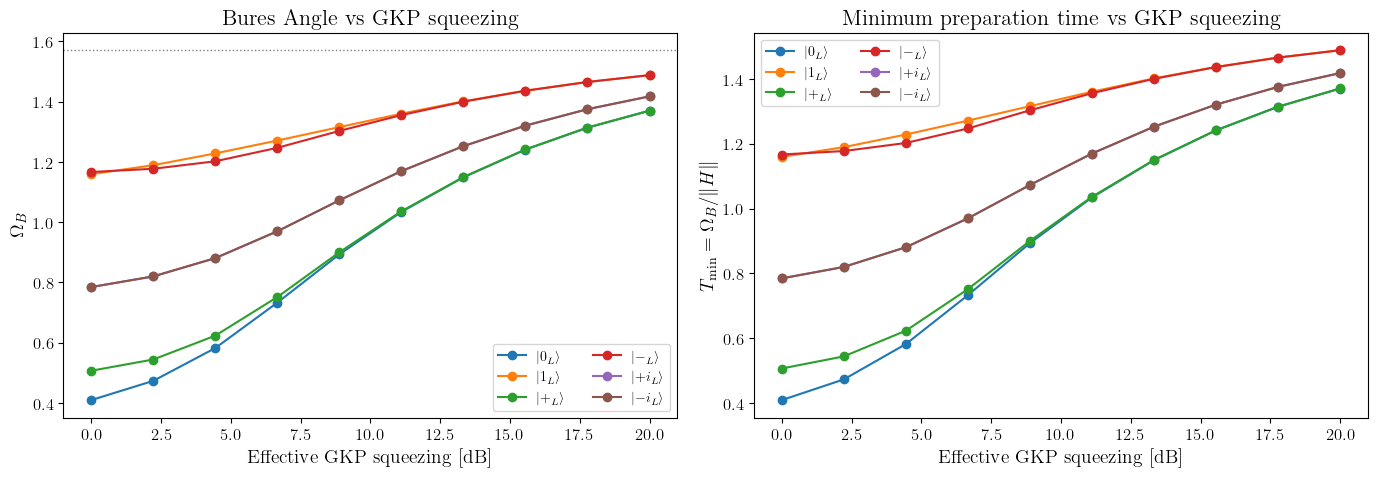

In [4]:
fig, (ax_angle, ax_time) = plt.subplots(1, 2, figsize=(14, 5))

for label, angles in bures_angles.items():
    ax_angle.plot(squeezings_db, angles, marker="o", label=rf"$\ket{{{label}}}$")
    ax_time.plot(squeezings_db, min_times[label], marker="o", label=rf"$\ket{{{label}}}$")

for ax in (ax_angle, ax_time):
    ax.set_xlabel(r"Effective GKP squeezing [dB]")
    ax.legend(fontsize=10, ncol=2)

ax_angle.set_ylabel(r"$\Omega_B$")
ax_angle.axhline(np.pi / 2, color="gray", linestyle=":", linewidth=1)
ax_angle.set_title(r"Bures Angle vs GKP squeezing")

ax_time.set_ylabel(r"$T_{\mathrm{min}} = \Omega_B / \lVert H \rVert$")
ax_time.set_title(r"Minimum preparation time vs GKP squeezing")

fig.tight_layout()
fig.savefig("../../figs/brachistochrone/gkp_quantum_speed_limit.pdf", bbox_inches="tight")
plt.show()